In [3]:
# Import all the packages (helper_function --> self-designed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)

# Load data and sort
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Create a copy for our helper function
df_full = df.copy()

# Drop the columns Terrasse and Restaurant (to prevent data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Define our target variable
target_col = "Tagesumsatz Restaurant"
print("Zielvariable:", target_col)

# Prepare time series data
# Make sure frequency is "daily"
df = df.set_index("Datum").asfreq("D")

# Make sure there are no NaN cells
df = df.ffill().bfill() 

# Create features / regressors
num_cols = df.select_dtypes(include=["number"]).columns
regressors = [c for c in num_cols if c != target_col]
print("Regressoren :", regressors)

# Create the DataFrame for our Prophet Models
df_p = df.reset_index().rename(columns={"Datum": "ds", target_col: "y"})

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (in %)."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


Zielvariable: Tagesumsatz Restaurant
Regressoren : ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)']


Prophet Model (with Cross Validation)

10:31:02 - cmdstanpy - INFO - Chain [1] start processing


Train_all Länge: 1475
Holdout-Test Länge: 306


10:31:02 - cmdstanpy - INFO - Chain [1] done processing
10:31:02 - cmdstanpy - INFO - Chain [1] start processing
10:31:02 - cmdstanpy - INFO - Chain [1] done processing
10:31:02 - cmdstanpy - INFO - Chain [1] start processing
10:31:03 - cmdstanpy - INFO - Chain [1] done processing
10:31:03 - cmdstanpy - INFO - Chain [1] start processing
10:31:03 - cmdstanpy - INFO - Chain [1] done processing
10:31:03 - cmdstanpy - INFO - Chain [1] start processing
10:31:03 - cmdstanpy - INFO - Chain [1] done processing
10:31:03 - cmdstanpy - INFO - Chain [1] start processing
10:31:03 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(r


 Cross validation results (Expanding Window, 7-day-forecast on train_all)


,train_end,test_start,test_end,MSE,RMSE,MAE,MAPE
0,2021-12-31,2022-01-01,2022-01-07,8.832531e+05,939.815469,699.239991,21.182770
1,2022-01-07,2022-01-08,2022-01-14,1.782578e+06,1335.132235,1218.596434,33.267528
2,2022-01-14,2022-01-15,2022-01-21,2.067490e+06,1437.876846,1288.996416,47.484184
3,2022-01-21,2022-01-22,2022-01-28,4.394881e+06,2096.397127,1752.337850,49.521077
4,2022-01-28,2022-01-29,2022-02-04,2.335298e+06,1528.168232,1387.717258,16.183200
...,...,...,...,...,...,...,...
153,2024-12-06,2024-12-07,2024-12-13,6.096735e+06,2469.156756,1743.310420,17.503205
154,2024-12-13,2024-12-14,2024-12-20,2.061261e+06,1435.709343,1266.454312,16.158661
155,2024-12-20,2024-12-21,2024-12-27,1.431218e+07,3783.143728,2917.977302,49.600021
156,2024-12-27,2024-12-28,2025-01-03,4.427711e+07,6654.104961,4551.741268,33.925576


...

,Datum,Ist,Vorhersage



Silvester im Holdout (31.12.):


,Datum,Ist,Vorhersage



Muttertag im Holdout:


,Datum,Ist,Vorhersage
1591,2025-05-11,40176.1,29589.666667


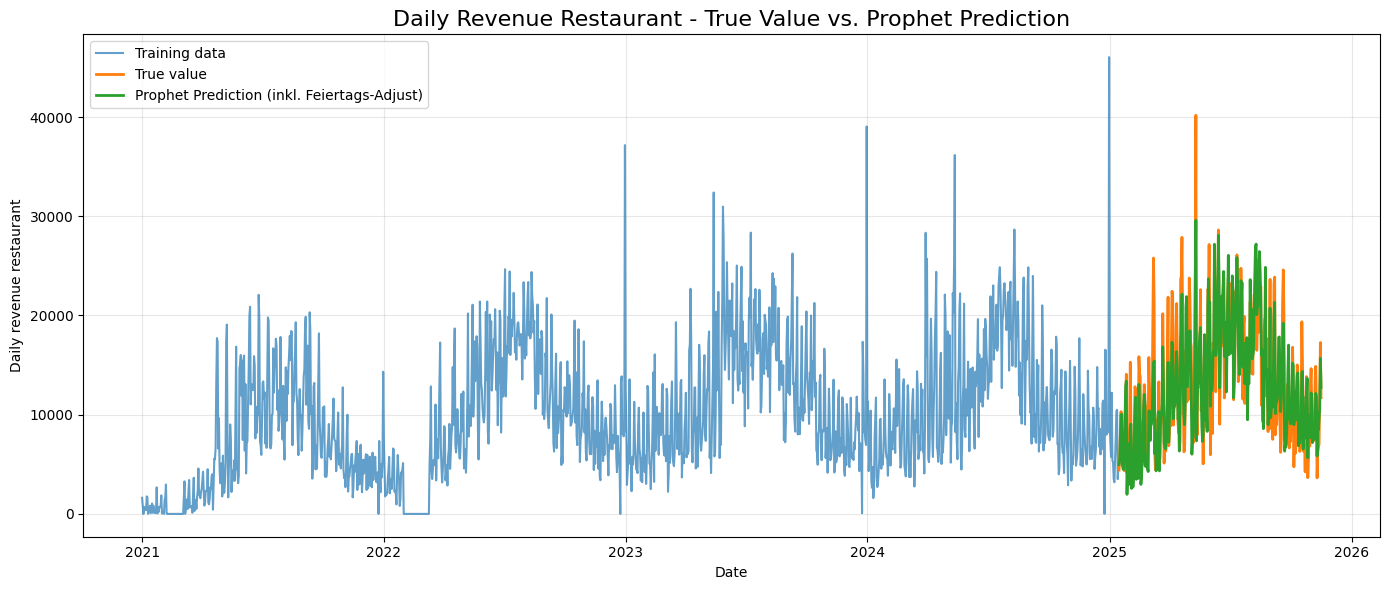

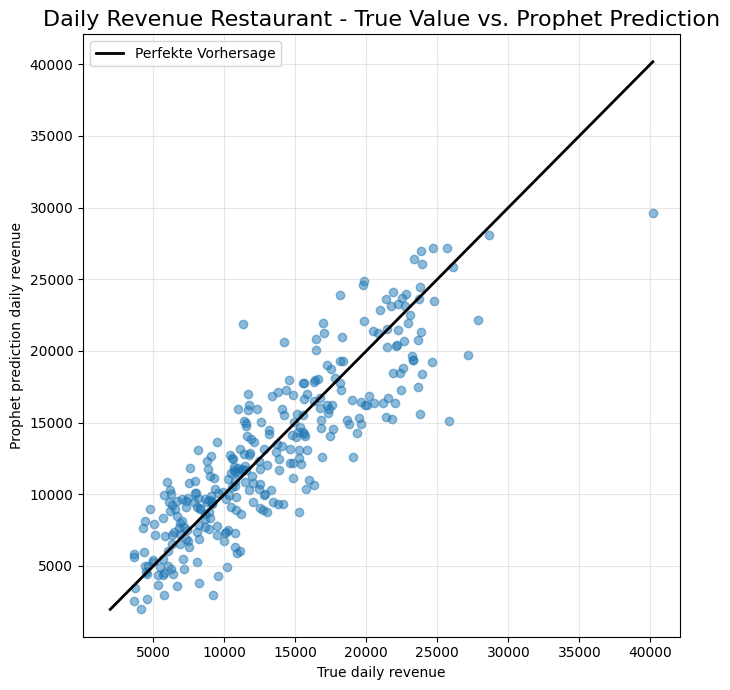

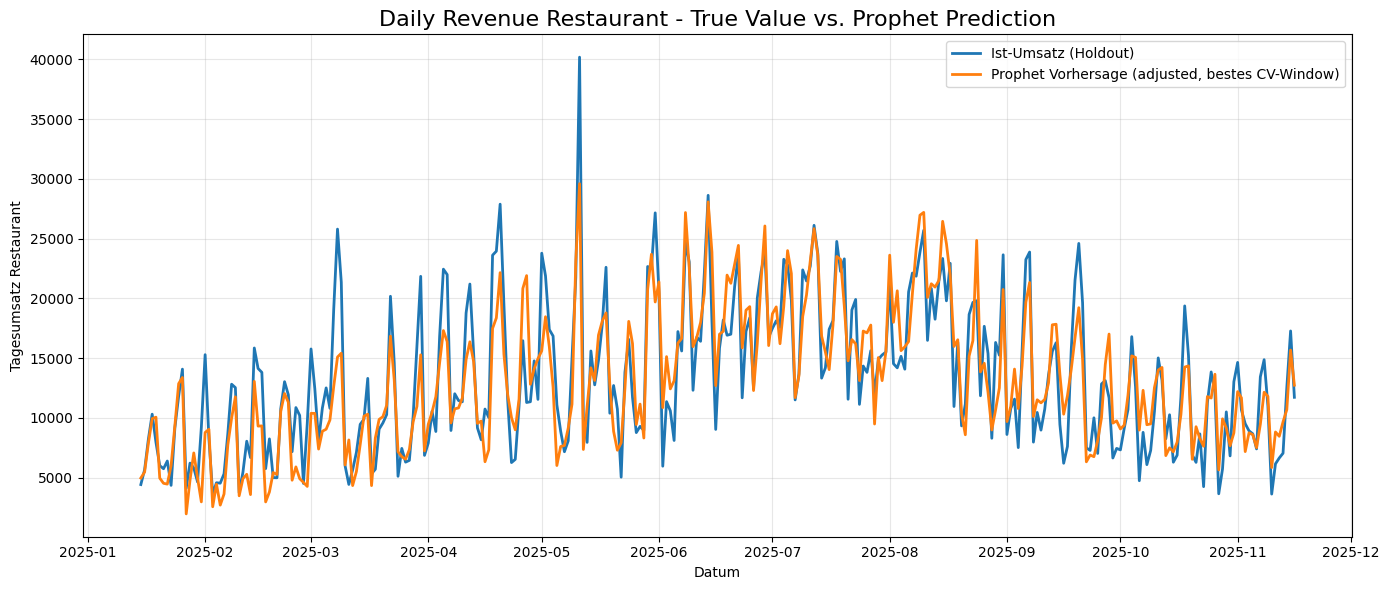

In [5]:
#Train/Test-Split
split_date = pd.Timestamp("2025-01-15")

train_all = df_p[df_p["ds"] < split_date].copy()
test_holdout = df_p[df_p["ds"] >= split_date].copy()

print("Train_all Länge:", len(train_all))
print("Holdout-Test Länge:", len(test_holdout))


# Defining Cross Validation: Expanding Window, 7-day-forecast
# Only on train_all data --> test_holdout will not be touched
horizon_days = 7      # 1 week
min_train_days = 365  # defining minimum days for first split

all_dates_train = train_all["ds"].sort_values().unique()

# Create space to save the cross validation results
cv_results = []

start_index = min_train_days

# Create the loop for cross validation
while start_index + horizon_days <= len(all_dates_train):

    # Date split for train_all data 
    train_end = all_dates_train[start_index - 1]
    test_start = all_dates_train[start_index]
    test_end = all_dates_train[start_index + horizon_days - 1]

    train_cv = train_all[train_all["ds"] <= train_end].copy()
    test_cv = train_all[(train_all["ds"] >= test_start) &
                        (train_all["ds"] <= test_end)].copy()

    # Sort the values
    # just in case the time series is not in order
    train_cv = train_cv.sort_values("ds")
    test_cv = test_cv.sort_values("ds")

    # Remove the special days (Christmas, New Year, Mothersday from the train_cv data)
    # We will later add a Holiday boost to the prediction but we train the model
    # on data that does not entail these outliers
    special_mask_train_cv = train_cv["ds"].apply(is_special_day)
    train_cv = train_cv[~special_mask_train_cv].copy()

    # Set-up the Prophet model
    m_cv = Prophet(
        daily_seasonality=False,  # there is no intraday seasonality --> daily revenue data
        weekly_seasonality=True,  # there is weekly seasonality in our data (Friday vs. Monday)
        yearly_seasonality=True,  # there is yearly seasonality in our data (Fall vs. Spring)
        seasonality_mode="multiplicative",  # The strength of seasonality scales with the level of the trend
        changepoint_prior_scale=0.16 # standard is 0.05 --> we chose 0.16 so that the model can react more on trends
    )
    # Add an additional seasonality component
    # Since a restaurant is an extremely cylcical business (on a yearly basis) we decided to implement an additional seasonal component.
    # Fourier = 16 to allow more Waves --> 16 Sine-Waves & 16 Cosine-Waves
    m_cv.add_seasonality(name="yearly_extra", period=365.25, fourier_order=16)

    # Add the regressors (features) to our Prophet model
    for reg in regressors:
        m_cv.add_regressor(reg)

    # Fit model (ds = Dates, y = target, regressors = features)
    m_cv.fit(train_cv[["ds", "y"] + regressors])

    # Create the future DataFrame for our Prophet for cross validation
    future_cv = test_cv[["ds"]].merge(
        df_p[["ds"] + regressors],
        on="ds",
        how="left"
    )

    forecast_test_cv = m_cv.predict(future_cv)
    forecast_test_cv = forecast_test_cv.sort_values("ds")

    
    # Holiday boost / adjustment for cross validation
    y_pred_adj = []
    for i, d in enumerate(forecast_test_cv["ds"]):
        d = pd.Timestamp(d)
        pred_value = forecast_test_cv.iloc[i]["yhat"]
        year = d.year

        # Christmas
        if is_christmas(d):
            avg = holiday_average_last_3_years(
                df_full,
                lambda y: pd.Timestamp(y, 12, 24),
                year,
                target_col
            )
            if avg is not None:
                pred_value = avg

        # New Year's Eve
        if is_silvester(d):
            avg = holiday_average_last_3_years(
                df_full,
                lambda y: pd.Timestamp(y, 12, 31),
                year,
                target_col
            )
            if avg is not None:
                pred_value = avg

        # Mothersday
        if is_mothers_day(d):
            avg = holiday_average_last_3_years(
                df_full,
                mothers_day,
                year,
                target_col
            )
            if avg is not None:
                pred_value = avg

        y_pred_adj.append(pred_value)

    y_true_cv = test_cv["y"].values
    y_pred_adj = np.array(y_pred_adj)

    # Define the metrics (within cross validation)
    fold_mse  = mean_squared_error(y_true_cv, y_pred_adj)
    fold_rmse = fold_mse ** 0.5
    fold_mae  = mean_absolute_error(y_true_cv, y_pred_adj)
    fold_mape = mape(y_true_cv, y_pred_adj)

    cv_results.append({
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "MSE": fold_mse,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "MAPE": fold_mape
    })

    # Next split, 7 days onwards
    start_index += horizon_days

# Show cross validation results
cv_df = pd.DataFrame(cv_results)
print("\n Cross validation results (Expanding Window, 7-day-forecast on train_all)")
display(cv_df)

# Choose the best window (comparing MAPE values)
best_window = cv_df.sort_values("MAPE").iloc[0]
best_train_end = best_window["train_end"]
best_test_start = best_window["test_start"]
best_test_end   = best_window["test_end"]

print("\nBest CV-Window (comparing MAPE):")
print(best_window)

# Window for training the final model
train_final = train_all[train_all["ds"] <= best_train_end].copy()

print("\nFinal window")
print("from:", train_final["ds"].min(), "until:", train_final["ds"].max())
print("Number of days of the window:", len(train_final))


# Final Model (after cross validation)
# Remove special days (Holidays)
special_mask_train_final = train_final["ds"].apply(is_special_day)
train_final = train_final[~special_mask_train_final].copy()

# Prophet-Modell (same parameters as in the cross validation)
m_final = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.16
)
m_final.add_seasonality(name="yearly_extra", period=365.25, fourier_order=16)

for reg in regressors:
    m_final.add_regressor(reg)

# Fit model (ds = Dates, y = target, regressors = features)
m_final.fit(train_final[["ds", "y"] + regressors])

# Create the future DataFrame for our Prophet for cross validation
future_final = test_holdout[["ds"]].merge(
    df_p[["ds"] + regressors],
    on="ds",
    how="left"
)

forecast_holdout = m_final.predict(future_final)
forecast_holdout = forecast_holdout.sort_values("ds")

# Prediction plus Holiday boost
# Also define the real values of the test_holdout as y_true_holdout
y_true_holdout = test_holdout["y"].values
y_pred_holdout = forecast_holdout["yhat"].values.copy()

for i, d in enumerate(forecast_holdout["ds"]):
    d = pd.Timestamp(d)
    year = d.year

    # Christmas
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full,
            lambda y_: pd.Timestamp(y_, 12, 24),
            year,
            target_col
        )
        if avg_xmas is not None:
            y_pred_holdout[i] = avg_xmas

    # New Year's Eve
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full,
            lambda y_: pd.Timestamp(y_, 12, 31),
            year,
            target_col
        )
        if avg_silvester is not None:
            y_pred_holdout[i] = avg_silvester

    # Mothersday
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full,
            mothers_day,
            year,
            target_col
        )
        if avg_mothers is not None:
            y_pred_holdout[i] = avg_mothers


# Evaluation metrics for the final model
mse_h  = mean_squared_error(y_true_holdout, y_pred_holdout)
rmse_h = mse_h ** 0.5
r2_h   = r2_score(y_true_holdout, y_pred_holdout)
mae_h  = mean_absolute_error(y_true_holdout, y_pred_holdout)
mape_h = mape(y_true_holdout, y_pred_holdout)

# Naive Baseline: Vortag als Prognose (nur auf Holdout)
full_series = df_p.set_index("ds")["y"]
holdout_series = full_series.loc[test_holdout["ds"]]
y_naive_holdout = holdout_series.shift(1).bfill().values

mse_naive_h = mean_squared_error(y_true_holdout, y_naive_holdout)
relative_MSE_h = mse_h / mse_naive_h

print("\nFINAL METRICS")
print(f"MSE          : {mse_h:.2f}")
print(f"RMSE         : {rmse_h:.2f}")
print(f"R²           : {r2_h:.4f}")
print(f"MAE          : {mae_h:.2f}")
print(f"MAPE         : {mape_h:.2f}%")
print(f"Relative MSE : {relative_MSE_h:.4f}")


# Comparison real data value and holiday boost prediction
results_holdout = pd.DataFrame({
    "Datum": test_holdout["ds"],
    "Ist": y_true_holdout,
    "Vorhersage": y_pred_holdout
})

print("\nChristmas real vs. prediction (24.12.):")
display(results_holdout[
    (results_holdout["Datum"].dt.month == 12) &
    (results_holdout["Datum"].dt.day == 24)
])

print("\nNew Year's Eve real vs. prediction (31.12.):")
display(results_holdout[
    (results_holdout["Datum"].dt.month == 12) &
    (results_holdout["Datum"].dt.day == 31)
])

print("\nMothersday real vs. prediction:")
results_mothers_holdout = results_holdout[
    results_holdout["Datum"].apply(lambda d: d == mothers_day(d.year))
]
display(results_mothers_holdout)

# Plots
# Time series plot: True vs. Prediction
plt.figure(figsize=(14,6))
plt.plot(train_all["ds"], train_all["y"], label="Training data", alpha=0.7)
plt.plot(results_holdout["Datum"], results_holdout["Ist"],
         label="True value", linewidth=2)
plt.plot(results_holdout["Datum"], results_holdout["Vorhersage"],
         label="Prophet Prediction", linewidth=2)

plt.title("Daily Revenue Restaurant - True Value vs. Prophet Prediction", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Daily revenue restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Scatter-Plot: True vs. Predicted
plt.figure(figsize=(7,7))
plt.scatter(y_true_holdout, y_pred_holdout, alpha=0.5)

min_val = min(y_true_holdout.min(), y_pred_holdout.min())
max_val = max(y_true_holdout.max(), y_pred_holdout.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, color="black", label="Perfect Prediction")

plt.title("Daily Revenue Restaurant - True Value vs. Prophet Prediction", fontsize=16)
plt.xlabel("True daily revenue")
plt.ylabel("Prophet prediction daily revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Time series plot: True vs. Prediction (compact)
plt.figure(figsize=(14,6))
plt.plot(results_holdout["Datum"], results_holdout["Ist"],
         label="Ist-Umsatz (Holdout)", linewidth=2)
plt.plot(results_holdout["Datum"], results_holdout["Vorhersage"],
         label="Prophet Prediction", linewidth=2)

plt.title("Daily Revenue Restaurant - True Value vs. Prophet Prediction", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Illustration of the seasonality

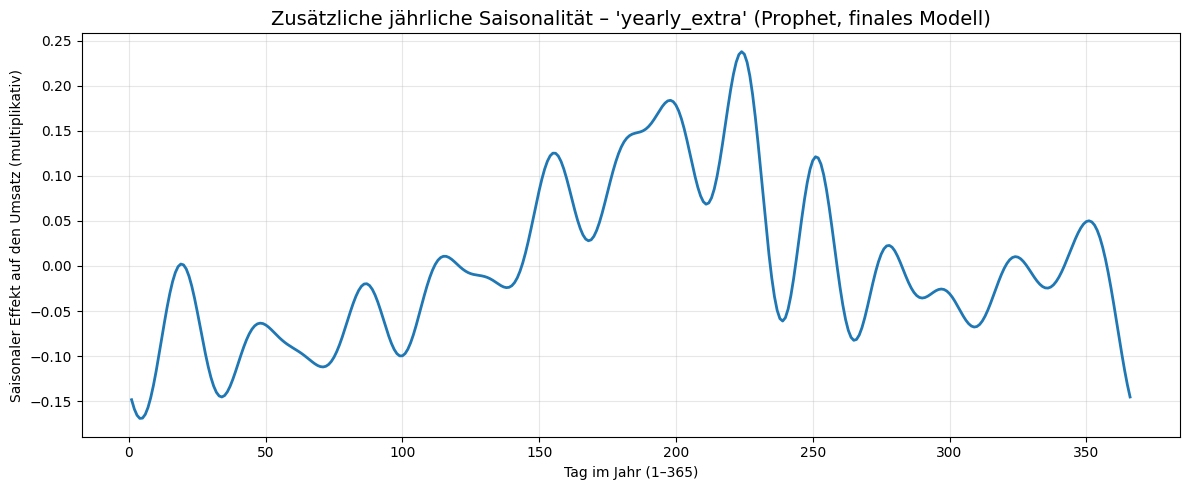

In [8]:
# Create an artificial year
future_year = pd.date_range("2024-01-01", "2024-12-31", freq="D")
future_year_df = pd.DataFrame({"ds": future_year})

# Add regressors
future_year_df = future_year_df.merge(
    df_p[["ds"] + regressors],
    on="ds",
    how="left"
)

# Forward Fill and Backward Fill in case there are NaN values
future_year_df[regressors] = future_year_df[regressors].ffill().bfill()

# Predict Prophet components for that year
forecast_year = m_final.predict(future_year_df)

# Prophet outputs the additional seasonality in the “yearly_extra” column
#This column is now available in forecast_year

# Calculate day of the year (1–365)
forecast_year["day_of_year"] = forecast_year["ds"].dt.dayofyear


# Plot of the yearly seasonality
plt.figure(figsize=(12, 5))
plt.plot(
    forecast_year["day_of_year"],
    forecast_year["yearly_extra"],
    linewidth=2
)

plt.title("Zusätzliche jährliche Saisonalität – 'yearly_extra' (Prophet, finales Modell)", fontsize=14)
plt.xlabel("Tag im Jahr (1–365)")
plt.ylabel("Saisonaler Effekt auf den Umsatz (multiplikativ)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
